In [22]:
import polars as pl
import options_data_utils
import warnings
from visualisation import utils
warnings.filterwarnings("ignore")
from importlib import reload
reload(options_data_utils)
from options_data_utils import get_cleaned_options_data, get_average_iv_for_delta_bucket, delta_thresholds_calls, delta_thresholds_puts, filter_atm, get_atm_vrps, get_otm_vrps
from vol_utils import get_daily_volatility
from format import format_chart
import matplotlib.pyplot as plt
from functools import reduce
def fold_join (dfs, join_on, how='left'):
    return reduce(lambda x, y: x.join(y, on=join_on, how=how), dfs)
# tlt_call = get_cleaned_options_data('XLE', (2023,2024), 'CALL')


In [45]:
from seaborn import kdeplot

@format_chart
def plot_multivariate_kernel_density(x, y,outliers, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 8))
    kdeplot(
        x=x, 
        y=y, 
        fill=True,
        cmap="rocket_r",
        cbar=True,
        ax=ax
    )
    ax.scatter(x[outliers], y[outliers], s=2.0, alpha=0.5, color='red', label='Outliers')
    ax.scatter(x, y,s=2.0, alpha=0.1, color='gray')
    cbar = ax.collections[0].colorbar
    cbar.set_label('Density')    
    return ax

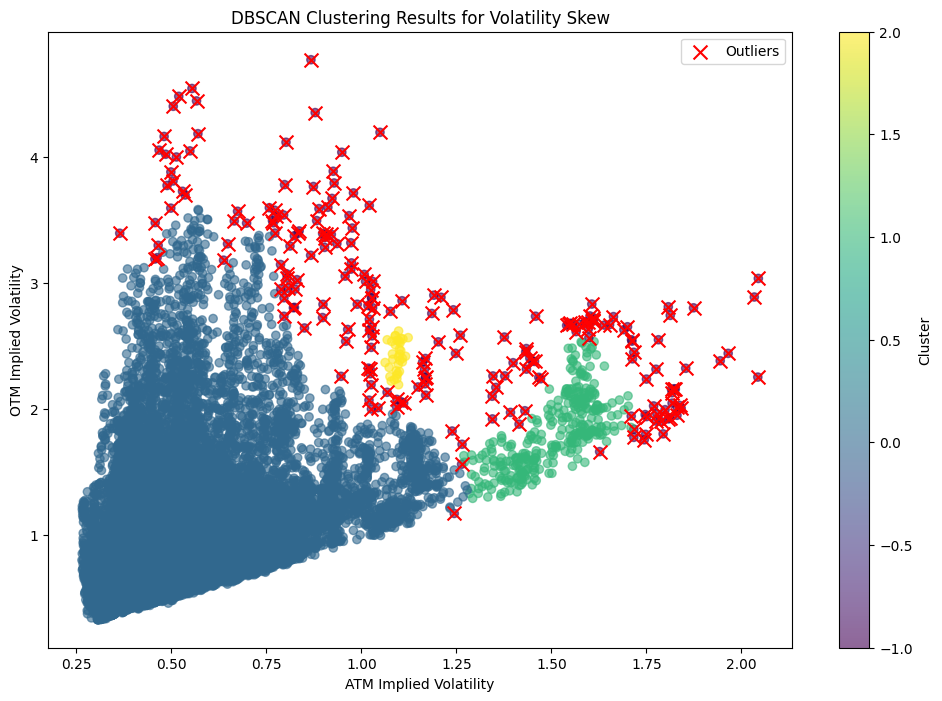

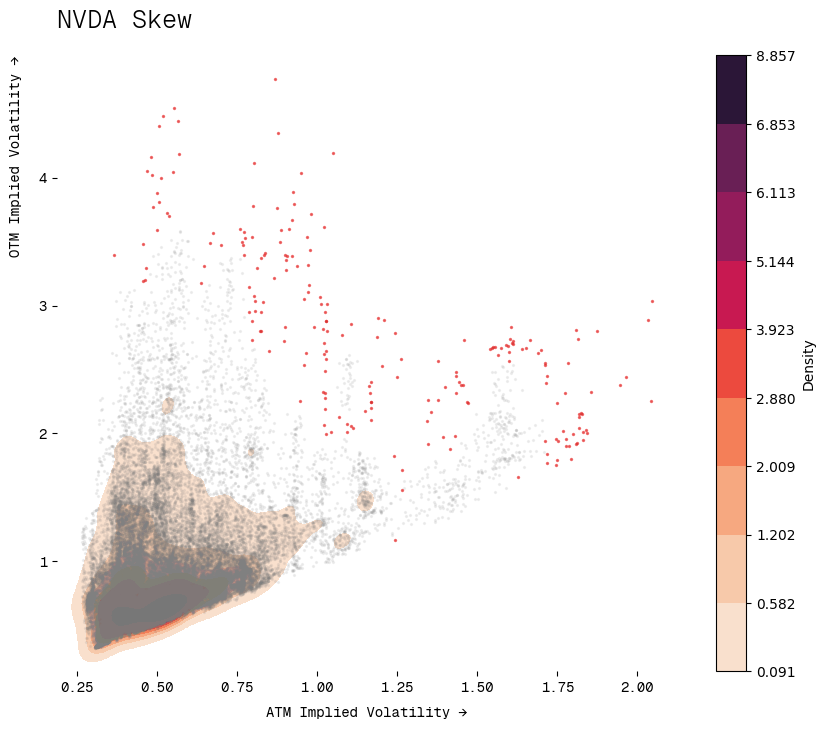

In [58]:
def build_skew (ticker):
    atm = get_atm_vrps(ticker).select(['timestamp','realized_volatility', 'implied_vol']).group_by('timestamp').agg(pl.col('implied_vol').mean(), pl.col('realized_volatility').mean()).rename({'implied_vol': 'atm_implied_vol'})
    otm = get_otm_vrps(ticker).select(['timestamp','realized_volatility', 'implied_vol']).group_by('timestamp').agg(pl.col('implied_vol').mean()).rename({'implied_vol': 'otm_implied_vol'})
    skew = atm.join(otm, on='timestamp').sort('timestamp').with_columns((pl.col('otm_implied_vol')/pl.col('atm_implied_vol')).alias('skew'))
    return skew
tsla = build_skew('NVDA')

clusters, outliers = detect_outliers_dbscan(tsla['atm_implied_vol'].to_numpy(), tsla['otm_implied_vol'].to_numpy(), eps=0.3, min_samples=15)
ax = plot_multivariate_kernel_density(x=tsla['atm_implied_vol'].to_numpy(), y=tsla['otm_implied_vol'].to_numpy(), outliers=outliers,xlabel='ATM Implied Volatility', ylabel='OTM Implied Volatility', title='NVDA Skew')

In [56]:
from dbsscan import DBSCANOutlierDetector
atm_vol_data = tsla['atm_implied_vol'].to_numpy()
otm_vol_data = tsla['otm_implied_vol'].to_numpy()
detector = DBSCANOutlierDetector(eps=0.3, min_samples=10)
detector.fit(atm_vol_data, otm_vol_data)

is_outlier, distance, cluster = detector.predict(0.48, 0.65)

print(f"Point (0.8215, 0.65):")
print(f"Is outlier: {is_outlier}")
print(f"Distance to nearest core point: {distance:.3f}")
print(f"Nearest cluster: {cluster}")

Point (0.8215, 0.65):
Is outlier: False
Distance to nearest core point: 0.006
Nearest cluster: 0


In [ ]:
xle = build_skew('XLE')
clusters, outliers = detect_outliers_dbscan(tsla['atm_implied_vol'].to_numpy(), tsla['otm_implied_vol'].to_numpy(), eps=0.3, min_samples=15)
ax = plot_multivariate_kernel_density(x=xle['atm_implied_vol'].to_numpy(), y=xle['otm_implied_vol'].to_numpy(), outliers=outliers,xlabel='ATM Implied Volatility', ylabel='OTM Implied Volatility', title='XLE Skew')

In [25]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

def detect_outliers_dbscan(atm_vol, otm_vol, eps=0.3, min_samples=10):
    X = np.column_stack([atm_vol, otm_vol])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)   
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(X_scaled)    
    return clusters, outliers

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from itertools import product

def find_optimal_eps(X, k=5):
    """
    Use k-distance graph to find optimal eps
    """
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    # Sort distances in ascending order
    distances = np.sort(distances[:, -1])
    
    # Plot k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(distances)), distances)
    plt.xlabel('Points')
    plt.ylabel(f'Distance to {k}th nearest neighbor')
    plt.title('K-distance Graph')
    
    # Find elbow point (you can visually inspect where the curve starts to elbow)
    return distances

def evaluate_dbscan_params(X, eps_range, min_samples_range):
    """
    Evaluate different combinations of eps and min_samples
    """
    results = []
    
    for eps, min_samples in product(eps_range, min_samples_range):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X)
        
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': n_noise / len(X)
        })
    
    return results

def plot_parameter_evaluation(X, results):
    """
    Visualize clustering results for different parameters
    """
    # Create a grid of the most interesting results
    unique_eps = sorted(set(r['eps'] for r in results))
    unique_min_samples = sorted(set(r['min_samples'] for r in results))
    
    fig, axes = plt.subplots(len(unique_min_samples), len(unique_eps), 
                            figsize=(4*len(unique_eps), 4*len(unique_min_samples)))
    fig.suptitle('DBSCAN Parameter Evaluation')
    
    for i, min_samples in enumerate(unique_min_samples):
        for j, eps in enumerate(unique_eps):
            result = next(r for r in results 
                        if r['eps'] == eps and r['min_samples'] == min_samples)
            
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            clusters = dbscan.fit_predict(X)
            
            ax = axes[i][j] if len(unique_min_samples) > 1 else axes[j]
            scatter = ax.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', alpha=0.6)
            ax.set_title(f'eps={eps:.2f}, min_samples={min_samples}\n'
                        f'clusters={result["n_clusters"]}, '
                        f'noise={result["noise_ratio"]:.2%}')
            ax.set_xticks([])
            ax.set_yticks([])
    
    plt.tight_layout()
    return fig

def tune_dbscan(atm_vol, otm_vol):
    """
    Main function to tune DBSCAN parameters
    """
    # Prepare data
    X = np.column_stack([atm_vol, otm_vol])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 1. Find optimal eps using k-distance graph
    distances = find_optimal_eps(X_scaled)
    plt.show()
    
    # 2. Based on k-distance graph, evaluate range of parameters
    eps_range = np.linspace(0.1, 0.5, 5)  # Adjust based on k-distance graph
    min_samples_range = [5, 10, 15, 20]
    
    results = evaluate_dbscan_params(X_scaled, eps_range, min_samples_range)
    
    # 3. Visualize results
    plot_parameter_evaluation(X_scaled, results)
    plt.show()
    
    # 4. Print summary statistics
    print("\nParameter Evaluation Summary:")
    for r in results:
        print(f"eps={r['eps']:.2f}, min_samples={r['min_samples']}: "
              f"{r['n_clusters']} clusters, {r['noise_ratio']:.2%} noise points")
    
    return results, X_scaled

# Example usage:
results, X_scaled = tune_dbscan(atm_vol_data, otm_vol_data)

In [ ]:

t = call_df.filter_expiration('20200221').with_columns((pl.col("strike") - pl.col("underlying_price")*1000).abs().alias('strike_distance')).group_by("trading_day").agg([
        pl.col('implied_vol').filter(pl.col('strike_distance') == pl.col('strike_distance').min()).mean()]).rename({"implied_vol": "around_atm_call_iv"}).sort('trading_day')
t = t.join(realised_vol.select('trading_day', 'annualized_volatility'), on='trading_day', how='left').sort('trading_day')
plt.plot(t['trading_day'], t['around_atm_call_iv'])
# plt.plot(t['trading_day'], t['annualized_volatility'])


In [8]:
from functools import lru_cache

@lru_cache(maxsize=10)
def get_iv_and_rv(ticker):
    call_df = pl.read_parquet(f'DATA/OPTIONS/{ticker}_CALL.parquet')
    realised_vol = get_daily_volatility(ticker).rename({"timestamp": "trading_day"}).filter(pl.col('trading_day').is_in(call_df['trading_day']))
    
    atm_implied_vol = call_df.with_columns((pl.col("strike") - pl.col("underlying_price")*1000).abs().alias('strike_distance')).group_by("trading_day").agg([
        pl.col('implied_vol').filter(pl.col('strike_distance') == pl.col('strike_distance').min()).mean()]).rename({"implied_vol": "around_atm_call_iv"})
    
    iv_and_rv = atm_implied_vol.join(realised_vol.select('trading_day', 'annualized_volatility'), on='trading_day', how='left').sort('trading_day')
    
    return iv_and_rv


# Example usage:
iv_and_rv_nvda = get_iv_and_rv('NVDA')
iv_and_rv_tsla = get_iv_and_rv('TSLA')
iv_and_rv_tlt = get_iv_and_rv('TLT')


@lru_cache(maxsize=10)
def get_vrp (ticker):
    df = get_iv_and_rv(ticker)
    return (df['around_atm_call_iv']/df['annualized_volatility']).to_numpy()


vrp_nvda = get_vrp('NVDA')
vrp_tsla = get_vrp('TSLA')
vrp_tlt = get_vrp('TLT')
vrp_gld = get_vrp('GLD')
vrp_slv = get_vrp('SLV')
vrp_lqd = get_vrp('LQD')
vrp_ijr = get_vrp('IJR')
vrp_mdy = get_vrp('MDY')
vrp_spy = get_vrp('SPY')


In [ ]:
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
x = iv_and_rv_nvda['annualized_volatility'].to_numpy()
y = iv_and_rv_nvda['around_atm_call_iv'].to_numpy()
m = OLS(y, sm.add_constant(x)).fit()
m.summary()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from format import format_chart

@format_chart
def plot_multiple_kernel_densities(data_dict, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Custom color palette inspired by Nord theme
    colors = ['#031E36','#0F2573','#294F50','#DBAB61','#04335A','#C3C3C3',  '#81A1C1', '#4C566A' ]
    
    for (label, data), color in zip(data_dict.items(), colors):
        sns.kdeplot(data=data, ax=ax, label=label, color=color, fill=True, alpha=0.4)

    ax.legend()
    
    return ax

# Example usage:
data_dict = {
    # 'TLT VRP': vrp_tlt,
    # 'NVDA VRP': vrp_nvda,
    # 'TSLA VRP': vrp_tsla,
    # 'GLD VRP': vrp_gld,
    # 'LQD VRP': vrp_lqd,
    'IJR VRP': vrp_ijr,
    'MDY VRP': vrp_mdy,
    'SPY VRP': vrp_spy
}

plot_multiple_kernel_densities(
    data_dict,
    xlabel='Volatility Risk Premium',
    ylabel='Density',
    title='Kernel Density of Volatility Risk Premium'
)

In [ ]:
@format_chart
def plot_line_chart(data, xlabel, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    for x, y in data:
        ax.plot(x, y)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    return ax

plot_line_chart([(iv_and_rv_nvda['trading_day'], iv_and_rv_nvda['around_atm_call_iv']/iv_and_rv_nvda['annualized_volatility']), (iv_and_rv_tlt['trading_day'], iv_and_rv_tlt['around_atm_call_iv']/iv_and_rv_tlt['annualized_volatility'])], 'Time', 'Around ATM Call IV', 'NVDA')


In [ ]:
import numpy as np
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series, maxlag=20)
    print(f"ADF Test for {name}:")
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    print(f"{'Stationary' if result[1] < 0.05 else 'Non-stationary'} at 5% significance level.\n")

# Test original series
adf_test(x, 'Annualized Volatility (x)')
adf_test(y, 'Around ATM Call IV (y)')

# Test first differences
# adf_test(np.diff(x), 'First Difference of Annualized Volatility (x)')
# adf_test(np.diff(y), 'First Difference of Around ATM Call IV (y)')

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
def engle_granger_test(y, x, alpha=0.05):
    """
    Perform Engle-Granger cointegration test and print the conclusion.
    
    Parameters:
    y : array-like
        The dependent variable time series
    x : array-like
        The independent variable time series
    alpha : float, optional
        Significance level for the test (default is 0.05)
    
    Returns:
    bool
        True if the series are cointegrated, False otherwise
    """
    # Step 1: Fit the long-run equilibrium regression
    model = OLS(y, sm.add_constant(x)).fit()
    residuals = model.resid

    # Step 2: Perform ADF test on the residuals
    adf_result = adfuller(residuals)
    
    # Print results
    print("Engle-Granger Cointegration Test Results:")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print("Critical Values:")
    for key, value in adf_result[4].items():
        print(f"  {key}: {value:.4f}")
    
    # Determine if the series are cointegrated
    is_cointegrated = adf_result[1] < alpha
    
    # Print conclusion
    if is_cointegrated:
        print("\nConclusion: The series are cointegrated.")
        print(f"We reject the null hypothesis of no cointegration at the {alpha} significance level.")
        print("There is evidence of a long-run equilibrium relationship between the variables.")
    else:
        print("\nConclusion: The series are not cointegrated.")
        print(f"We fail to reject the null hypothesis of no cointegration at the {alpha} significance level.")
        print("There is no evidence of a long-run equilibrium relationship between the variables.")
    
    return is_cointegrated

# Example usage
x = iv_and_rv['annualized_volatility'].to_numpy()
y = iv_and_rv['around_atm_call_iv'].to_numpy()


print(engle_granger_test(y, x))

from statsmodels.tsa.vector_ar.vecm import coint_johansen

def johansen_test(y, x):
    # Combine the series
    data = np.column_stack((y, x))
    
    # Perform Johansen test
    result = coint_johansen(data, det_order=0, k_ar_diff=1)
    
    print("Johansen Cointegration Test Results:")
    print(f"Trace statistic: {result.lr1}")
    print(f"Critical values (90%, 95%, 99%): {result.cvt}")
    
    return result

# Example usage
result = johansen_test(y, x)
print(result)

def fit_ecm(y, x):
    # Step 1: Estimate the long-run equilibrium
    model = OLS(y, sm.add_constant(x)).fit()
    residuals = model.resid
    
    # Step 2: Estimate the ECM
    dy = np.diff(y)
    dx = np.diff(x)
    res_lag = residuals[:-1]
    
    ecm = OLS(dy, sm.add_constant(np.column_stack((dx, res_lag)))).fit()
    
    print("Error Correction Model Results:")
    print(ecm.summary())
    
    return ecm

# Example usage

ecm = fit_ecm(y, x)

In [ ]:
def calculate_half_life(y, x):
    # Estimate the cointegrating relationship
    model = OLS(y, sm.add_constant(x)).fit()
    residuals = model.resid
    
    # Estimate the rate of mean reversion
    lag_residuals = residuals[:-1]
    delta_residuals = residuals[1:] - residuals[:-1]
    
    model = OLS(delta_residuals, sm.add_constant(lag_residuals)).fit()
    
    # Calculate half-life
    half_life = -np.log(2) / model.params[1]
    
    print(f"Half-life of mean reversion: {half_life:.2f} periods")
    
    return half_life

# Example usage
half_life = calculate_half_life(y, x)

In [ ]:

@format_chart
def plot_iv_and_rv (iv_and_rv):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(iv_and_rv['trading_day'][1:], iv_and_rv['around_atm_call_iv'][1:], label='Implied Volatility', color="#071777", linewidth=0.9)
    ax.plot(iv_and_rv['trading_day'][:-1], iv_and_rv['annualized_volatility'][:-1], label='Realized Volatility', color="#2d3656", linewidth=0.9)
    return ax

@format_chart
def plot_iv_and_rv_pct_change (iv_and_rv):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(iv_and_rv['trading_day'], iv_and_rv['around_atm_call_iv'].pct_change(), label='Implied Volatility', color="#071777", linewidth=0.9)
    ax.plot(iv_and_rv['trading_day'], iv_and_rv['annualized_volatility'].pct_change(), label='Realized Volatility', color="#2d3656", linewidth=0.9)
    return ax

realised_vol = get_daily_volatility(ticker).rename({"timestamp": "trading_day"}).filter(pl.col('trading_day').is_in(call_df['trading_day']))
# atm_implied_vol = get_average_iv_for_delta_bucket(call_df, delta_thresholds_calls,'around_atm_call')

atm_implied_vol = call_df.with_columns((pl.col("strike") - pl.col("underlying_price")*1000).abs().alias('strike_distance')).group_by("trading_day").agg([
    pl.col('implied_vol').filter(pl.col('strike_distance') == pl.col('strike_distance').min()).mean()]).rename({"implied_vol": "around_atm_call_iv"})
# print(atm_implied_vol.shape)
# print(atm_implied_vol.null_count())
iv_and_rv = atm_implied_vol.join(realised_vol.select('trading_day', 'annualized_volatility'), on='trading_day', how='left').sort('trading_day')

# np.corr
# plot_iv_and_rv(iv_and_rv)
np.corrcoef(iv_and_rv['around_atm_call_iv'][:-10], iv_and_rv['annualized_volatility'][10:])
# iv_and_rv
# plot_iv_and_rv(iv_and_rv)


In [88]:
import numpy as np
from bisect import bisect_left
def find_neighbors(sorted_list, num):
    if isinstance(sorted_list, np.ndarray):  # Use np.ndarray instead of np.array
        sorted_list = sorted_list.tolist()
    if not sorted_list:
        return []
    idx = bisect_left(sorted_list, num)
    start = max(0, idx - 2)  # Ensure we don't go out of bounds
    end = min(len(sorted_list), idx + 2)  # Include the number and 5 after it
    return sorted_list[start:end]

In [ ]:
t

In [ ]:
find_neighbors(t['strike'].unique().sort().to_list(), t['underlying_price'].mean()*1000)

In [79]:
t = call_df.filter_day("20190920")

In [ ]:
call_df['underlying_price'].max() - call_df['underlying_price'].min()

In [ ]:
class Ticker:
    def __init__ (self, ticker):
        self.ticker = ticker
        self.call_df = pl.read_parquet(f'DATA/OPTIONS/{ticker}_CALL.parquet')
        self.put_df = pl.read_parquet(f'DATA/OPTIONS/{ticker}_PUT.parquet')
        

In [ ]:
# pl.read_parquet('CALL/IJR/IJR_2023_2024.parquet')
pl.read_parquet('PUT/MDY/MDY_2021_2022.parquet')

In [ ]:
import os
import glob
t = pl.read_csv('important_tickers.csv')['ticker'].to_list()
for ticker in t:
    parquet_files = glob.glob(os.path.join(f"CALL/{ticker}/", "*.parquet"))
    for file in parquet_files:
        df = pl.read_parquet(file)
        if df.shape[0] < 1e6:
            print(f"Empty file: {file}")
    # pl.read_parquet(f'CALL/{ticker}/{}')

In [ ]:
import os
import glob
t = os.listdir('PUT/')
for ticker in t:
    parquet_files = glob.glob(os.path.join(f"PUT/{ticker}/", "*.parquet"))
    for file in parquet_files:
        df = pl.read_parquet(file)
        if df.shape[0] == 0:
            print(f"Empty file: {file}")
    # pl.read_parquet(f'PUT/{ticker}/{}')

In [ ]:
put_df=get_cleaned_options_data('TSLA', 'PUT')

In [ ]:
put_df

In [ ]:
for tikcers in t:
    try:
        call_df=get_cleaned_options_data(tikcers, 'CALL')
        put_df=get_cleaned_options_data(tikcers, 'PUT')
        if len(call_df) > 2e6:
            call_df.write_parquet(f'DATA/OPTIONS/{tikcers}_CALL.parquet')
        if len(put_df) > 2e6:
            put_df.write_parquet(f'DATA/OPTIONS/{tikcers}_PUT.parquet')
        print(tikcers)
        print(len(call_df))
        print(len(put_df))
    except:
        print(f'Error with {tikcers}')

In [ ]:
def

In [132]:
call_df = pl.read_parquet('DATA/OPTIONS/TLT_CALL.parquet')
put_df = pl.read_parquet('DATA/OPTIONS/TLT_PUT.parquet')

In [134]:
one_month_expiry = (pl.col('days_to_expiry') >= 27) & (pl.col('days_to_expiry') < 32)
call_df = call_df.with_columns(
    (pl.col('expiration') - pl.col('trading_day')).dt.total_days().alias('days_to_expiry')
).filter(one_month_expiry)
put_df = put_df.with_columns(
    (pl.col('expiration') - pl.col('trading_day')).dt.total_days().alias('days_to_expiry')
).filter(one_month_expiry)

In [ ]:
put_df = put_df.filter(pl.col('delta').is_in([0.0,1.0]).not_())

In [ ]:
put_df

In [ ]:
put_df.filter_day('20190920')

In [ ]:
put_df.filter_day('20190920')

In [135]:
delta_thresholds_puts = {
    "very_deep_otm_put": (-0.05, 0.0),    # 5-delta
    "deep_otm_put": (-0.15, -0.05),       # 10-delta
    "otm_put": (-0.30, -0.20),            # 25-delta
    "around_atm_put": (-0.52, -0.48),     # 50-delta
    "itm_put": (-0.75, -0.65),
    "deep_itm_put": (-0.90, -0.80),
    "very_deep_itm_put": (-1.0, -0.90)
}

delta_thresholds_calls = {
    "very_deep_otm_call": (0.0, 0.05),    # 5-delta
    "deep_otm_call": (0.05, 0.15),        # 10-delta
    "otm_call": (0.20, 0.30),             # 25-delta
    "around_atm_call": (0.48, 0.52),      # 50-delta
    "itm_call": (0.65, 0.75),
    "deep_itm_call": (0.80, 0.90),
    "very_deep_itm_call": (0.90, 1.0)
}

In [ ]:
[get_average_iv_for_delta_bucket(put_df,  delta_thresholds_puts, k) for k in delta_thresholds_puts.keys()][0]

In [137]:
def get_implied_volatilities_for_strikes (call_df, put_df):
    call_iv = fold_join([get_average_iv_for_delta_bucket(call_df,  delta_thresholds_calls, k) for k in delta_thresholds_calls.keys()],
    join_on = 'trading_day',
    how='left'   
    )
    put_iv  = fold_join([get_average_iv_for_delta_bucket(put_df,  delta_thresholds_puts, k) for k in delta_thresholds_puts.keys()],
    join_on = 'trading_day',
    how='left'   
    )
    return call_iv.join(put_iv, on='trading_day', how='left')

iv_df = get_implied_volatilities_for_strikes(call_df, put_df)
# del call_df
# del put_df

In [ ]:
iv_df

In [139]:
iv_df = iv_df.with_columns([
    pl.col("trading_day")
    .dt.strftime(format="%b %Y")  # Formats as "Jan 2023", "Feb 2023", etc.
    .alias("month_year")
])

In [ ]:
iv_df

In [ ]:

@format_chart
def plot_skew_otm (iv_df, ylabel, xlabel, title ):

    fig, ax = plt.subplots(figsize=(15, 6))   
    # ax.plot(iv_df['trading_day'], iv_df['otm_skew'])
    ax.plot(iv_df['month_year'],iv_df['deep_otm_skew'], color="#182e3f")
    # plt.tight_layout(pad=10.0)  # Add extra padding around the plot
    # Rotate xticks and add padding
    plt.xticks(rotation=45, ha='right')  # Rotate the x-ticks 45 degrees, aligned to the right

# Use plt.tight_layout, not ax.tight_layout
    return ax

plot_skew_otm(iv_df, ylabel="skew", xlabel='time', title='SKEW')

In [142]:
iv_df = iv_df.with_columns([
    ((pl.col('otm_put_iv') - pl.col('otm_call_iv'))/(pl.col('around_atm_put_iv'))).alias('otm_skew'), 
    ((pl.col('deep_otm_put_iv') - pl.col('deep_otm_call_iv'))/(pl.col('around_atm_put_iv'))).alias('deep_otm_skew'), 
    ((pl.col('very_deep_otm_put_iv') - pl.col('very_deep_otm_call_iv'))/(pl.col('around_atm_put_iv'))).alias('very_deep_otm_skew'), 
])

In [ ]:
iv_df['otm_skew']

In [ ]:
plot_skew_otm(iv_df, ylabel=' SKEW', title='DEEP OTM PUT IV - DEEP OTM CALL (TLT)', xlabel='Time')

In [ ]:
import matplotlib.pyplot as plt
from importlib import reload
import format
reload(format)
from format import format_chart

@format_chart
def plot_smile (iv_df, option_type='call', ticks_transform=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    cols = [col for col in iv_df.columns if option_type in col]
    ax.plot(cols, iv_df.select(cols).row(589))
    return ax




@format_chart
def plot_skew_very_deep_otm (iv_df, ylabel, xlabel, title):
    fig, ax = plt.subplots(figsize=(10, 6))   
    # ax.plot(iv_df['trading_day'], iv_df['otm_skew'])
    ax.plot(iv_df['trading_day'], iv_df['very_deep_otm_skew'], color="#182e3f")
    return ax

@format_chart
def plot_skew_deep_otm (iv_df):
    fig, ax = plt.subplots(figsize=(10, 6))   
    ax.plot(iv_df['trading_day'], iv_df['deep_otm_skew'])
    # ax.plot(iv_df['trading_day'], iv_df['deep_otm_skew'])
    return ax

@format_chart
def plot_skew_scatter (iv_df):
    fig, ax = plt.subplots(figsize=(10, 6))   
    ax.scatter(iv_df['otm_skew'], iv_df['deep_otm_skew'])
    # ax.plot(iv_df['trading_day'], iv_df['deep_otm_skew'])
    return ax


# plot_skew_very_deep_otm(iv_df, ylabel='← CALL SKEW / PUT SKEW →', title='DEEP OTM PUT IV - DEEP OTM CALL (TLT)', xlabel='Time →')


In [ ]:
↑